<a href="https://colab.research.google.com/github/shanusushmita/CS-6140-Machine-Learning-Course-/blob/main/Instance_Based_Learning_KD%2C_FAISS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Example image](https://upload.wikimedia.org/wikipedia/commons/0/02/Northeastern_Wordmark.svg)

## KD Tree Example

Copyright: Prof. Shanu Sushmita

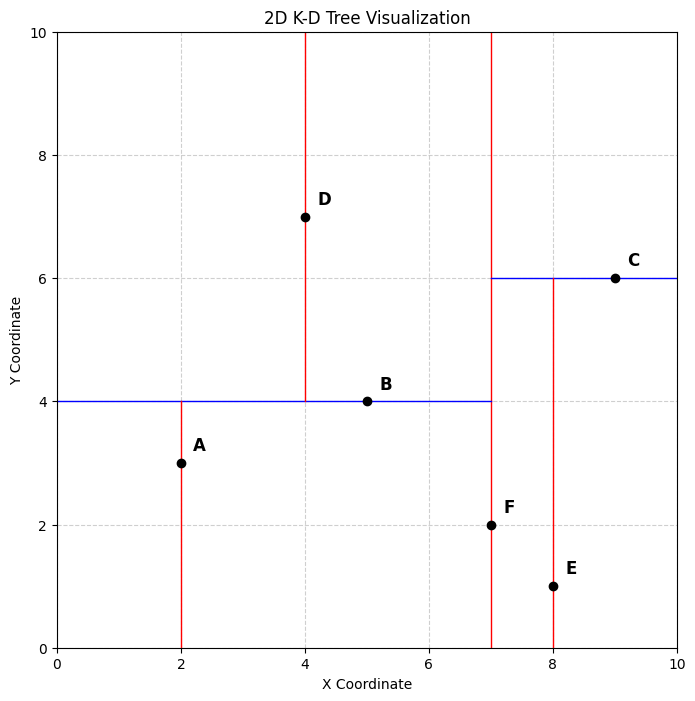

In [1]:
import matplotlib.pyplot as plt

# Data from your image: (x, y, label)
points = [
    (2, 3, 'A'), (5, 4, 'B'), (9, 6, 'C'),
    (4, 7, 'D'), (8, 1, 'E'), (7, 2, 'F')
]

def draw_kd_tree(points, depth=0, x_bounds=(0, 10), y_bounds=(0, 10)):
    if not points:
        return

    # Alternate between x (axis 0) and y (axis 1)
    axis = depth % 2

    # Sort points by the current axis and pick the median
    points.sort(key=lambda x: x[axis])
    median_idx = len(points) // 2
    node = points[median_idx]

    # Draw the splitting line
    if axis == 0:  # Vertical split (X-axis)
        plt.plot([node[0], node[0]], [y_bounds[0], y_bounds[1]], 'r-', linewidth=1)
        draw_kd_tree(points[:median_idx], depth + 1, (x_bounds[0], node[0]), y_bounds)
        draw_kd_tree(points[median_idx + 1:], depth + 1, (node[0], x_bounds[1]), y_bounds)
    else:  # Horizontal split (Y-axis)
        plt.plot([x_bounds[0], x_bounds[1]], [node[1], node[1]], 'b-', linewidth=1)
        draw_kd_tree(points[:median_idx], depth + 1, x_bounds, (y_bounds[0], node[1]))
        draw_kd_tree(points[median_idx + 1:], depth + 1, x_bounds, (node[1], y_bounds[1]))

    # Plot the point itself
    plt.scatter(node[0], node[1], color='black', zorder=5)
    plt.text(node[0] + 0.2, node[1] + 0.2, node[2], fontsize=12, fontweight='bold')

# Setup the plot
plt.figure(figsize=(8, 8))
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.title("2D K-D Tree Visualization")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle='--', alpha=0.6)

# Execute
draw_kd_tree(points)
plt.show()

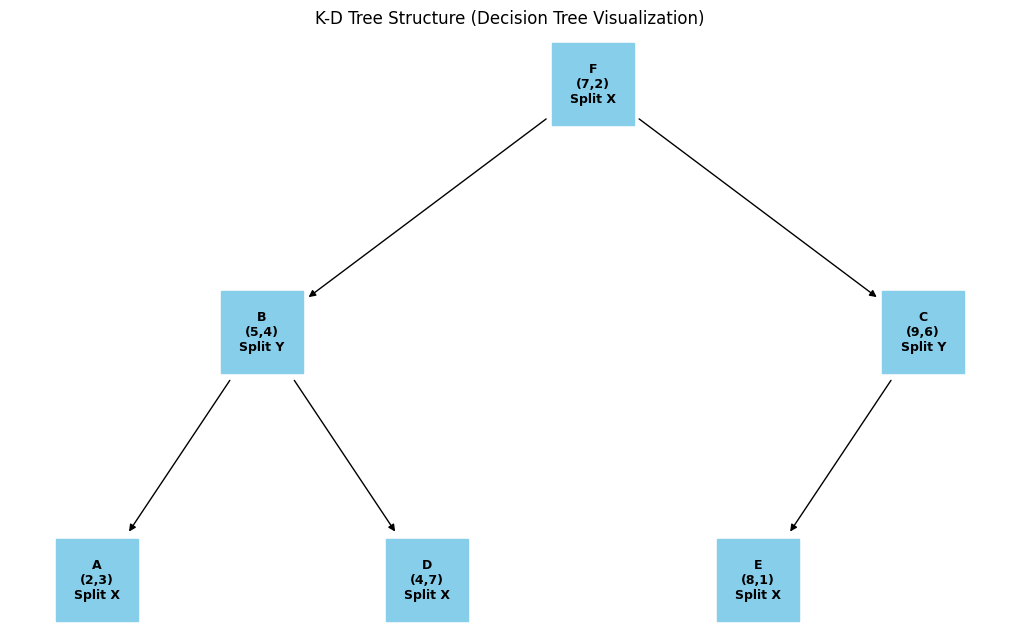

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

# Data from image: (x, y, Label)
points = [
    (2, 3, 'A'), (5, 4, 'B'), (9, 6, 'C'),
    (4, 7, 'D'), (8, 1, 'E'), (7, 2, 'F')
]

class Node:
    def __init__(self, point, depth, left=None, right=None):
        self.point = point
        self.depth = depth
        self.left = left
        self.right = right
        self.axis = depth % 2 # 0 for x, 1 for y

def build_kd_tree(pts, depth=0):
    if not pts:
        return None

    # Alternate between X (depth 0, 2...) and Y (depth 1, 3...)
    axis = depth % 2
    pts.sort(key=lambda x: x[axis])
    median_idx = len(pts) // 2

    return Node(
        point=pts[median_idx],
        depth=depth,
        left=build_kd_tree(pts[:median_idx], depth + 1),
        right=build_kd_tree(pts[median_idx + 1:], depth + 1)
    )

def add_to_graph(node, G, pos_val=0, width=2.0, level=0, parent=None):
    if node is None:
        return

    # Create node label with coordinate and current splitting axis
    axis_name = 'X' if node.axis == 0 else 'Y'
    label = f"{node.point[2]}\n({node.point[0]},{node.point[1]})\nSplit {axis_name}"

    G.add_node(label, pos=(pos_val, -level))
    if parent:
        G.add_edge(parent, label)

    # Recursively add children
    add_to_graph(node.left, G, pos_val - width/2, width/2, level + 1, label)
    add_to_graph(node.right, G, pos_val + width/2, width/2, level + 1, label)

# 1. Build the Tree
root = build_kd_tree(points)

# 2. Setup the Graph for Plotting
G = nx.DiGraph()
add_to_graph(root, G)
pos = nx.get_node_attributes(G, 'pos')

# 3. Draw
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_size=3500, node_color='skyblue',
        font_size=9, font_weight='bold', arrows=True, node_shape='s')

plt.title("K-D Tree Structure (Decision Tree Visualization)")
plt.show()

## KNN Search with K-D Tree

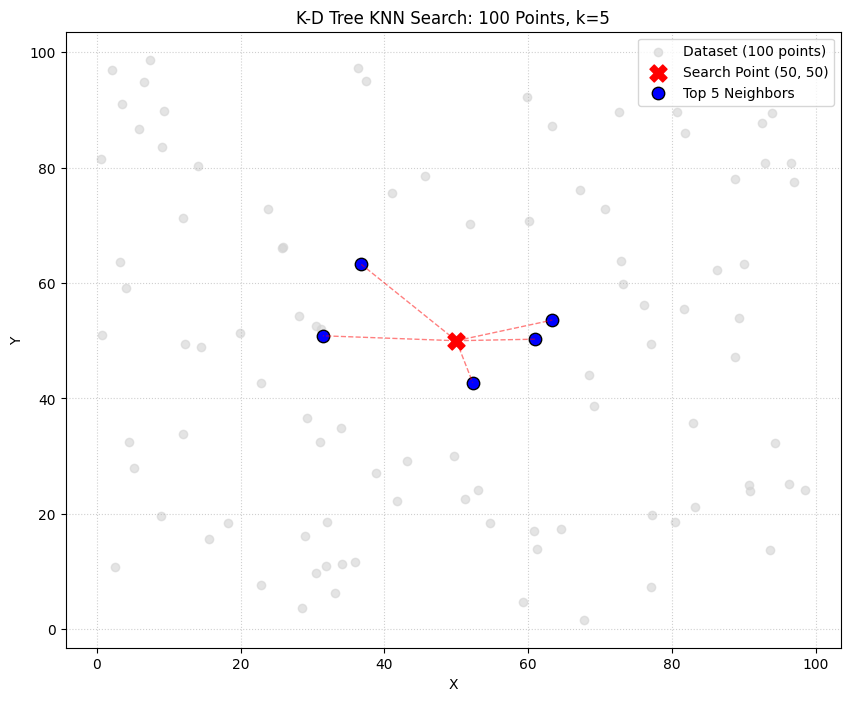

Indices of nearest points: [48 73 81 51 80]
Distances: [ 7.59 10.96 13.82 18.58 18.7 ]


In [3]:
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

# 1. Generate a bigger dataset (100 random points)
np.random.seed(42) # For consistent results
num_points = 100
points = np.random.uniform(0, 100, size=(num_points, 2))

# 2. Build the K-D Tree
tree = KDTree(points)

# 3. Define search parameters
search_point = np.array([50, 50])
k_neighbors = 5

# 4. Query the tree for the 5 nearest neighbors
distances, indices = tree.query(search_point, k=k_neighbors)

# 5. Visualization
plt.figure(figsize=(10, 8))

# Plot all data points
plt.scatter(points[:, 0], points[:, 1], c='lightgrey', alpha=0.6, label='Dataset (100 points)')

# Plot the search point
plt.scatter(search_point[0], search_point[1], c='red', marker='X', s=150, label='Search Point (50, 50)', zorder=5)

# Highlight the k-nearest neighbors
plt.scatter(points[indices, 0], points[indices, 1], c='blue', s=80, edgecolors='black', label=f'Top {k_neighbors} Neighbors')

# Draw lines to the neighbors for clarity
for idx in indices:
    plt.plot([search_point[0], points[idx, 0]], [search_point[1], points[idx, 1]], 'r--', linewidth=1, alpha=0.5)

plt.title(f"K-D Tree KNN Search: 100 Points, k={k_neighbors}")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Indices of nearest points: {indices}")
print(f"Distances: {np.round(distances, 2)}")

In [5]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 54.8 MB/s eta 0:00:00


In [6]:
import faiss
import numpy as np

d = 128
xb = np.random.random((100, d)).astype('float32')

index = faiss.IndexFlatL2(d)
index.add(xb)

xq = np.random.random((1, d)).astype('float32')
D, I = index.search(xq, k=3)

print("Nearest indices:", I)
print("Distances:", D)


Nearest indices: [[30 66 53]]
Distances: [[17.095703 17.405525 17.590698]]
